In [1]:
# EXTRA WORK SECTION 1
# Stemming
# Reducing words to their root form by cutting off endings
import nltk
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

# STEMMING
stemmer_porter   = PorterStemmer()
stemmer_snowball = SnowballStemmer('english')

# Test words covering different word forms
test_words = [
    'running', 'runs', 'runner',
    'studying', 'studies', 'studied',
    'caring', 'cares', 'carefully',
    'processing', 'processes', 'processed',
    'computing', 'computers', 'computational'
]

print("STEMMING — PORTER STEMMER")
print("=" * 55)
print(f"{'Original Word':<20} {'Stemmed Form':<20}")
print("-" * 40)
for word in test_words:
    stemmed = stemmer_porter.stem(word)
    print(f"  {word:<20} →  {stemmed}")

print("\nSTEMMING — SNOWBALL STEMMER")
print("=" * 55)
print(f"{'Original Word':<20} {'Stemmed Form':<20}")
print("-" * 40)
for word in test_words:
    stemmed = stemmer_snowball.stem(word)
    print(f"  {word:<20} →  {stemmed}")

# Apply stemming to a full sentence
sentence = "The students are studying NLP concepts and building computing systems."
tokens = word_tokenize(sentence.lower())
stemmed_sentence = [stemmer_porter.stem(w) for w in tokens]

print(f"\nORIGINAL SENTENCE:")
print(f"  {sentence}")
print(f"\nAFTER STEMMING:")
print(f"  {stemmed_sentence}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


STEMMING — PORTER STEMMER
Original Word        Stemmed Form        
----------------------------------------
  running              →  run
  runs                 →  run
  runner               →  runner
  studying             →  studi
  studies              →  studi
  studied              →  studi
  caring               →  care
  cares                →  care
  carefully            →  care
  processing           →  process
  processes            →  process
  processed            →  process
  computing            →  comput
  computers            →  comput
  computational        →  comput

STEMMING — SNOWBALL STEMMER
Original Word        Stemmed Form        
----------------------------------------
  running              →  run
  runs                 →  run
  runner               →  runner
  studying             →  studi
  studies              →  studi
  studied              →  studi
  caring               →  care
  cares                →  care
  carefully            →  care
  processing  

In [2]:
# Lemmatization
# Reducing words to their real dictionary form
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

# Test words same list as stemming for easy comparison
test_words = [
    'running', 'runs', 'runner',
    'studying', 'studies', 'studied',
    'caring', 'cares', 'carefully',
    'processing', 'processes', 'processed',
    'better', 'best', 'good'
]

print("LEMMATIZATION — WORDNET LEMMATIZER")
print("=" * 55)
print(f"{'Original Word':<20} {'Verb Form':<20} {'Noun Form'}")
print("-" * 55)
for word in test_words:
    lemma_verb = lemmatizer.lemmatize(word, pos='v')  # as verb
    lemma_noun = lemmatizer.lemmatize(word, pos='n')  # as noun
    print(f"  {word:<20} {lemma_verb:<20} {lemma_noun}")

# Apply to full sentence
sentence = "The students are studying NLP concepts and building computing systems."
tokens = word_tokenize(sentence.lower())
lemmatized = [lemmatizer.lemmatize(w, pos='v') for w in tokens]

print(f"\nORIGINAL SENTENCE:")
print(f"  {sentence}")
print(f"\nAFTER LEMMATIZATION:")
print(f"  {lemmatized}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


LEMMATIZATION — WORDNET LEMMATIZER
Original Word        Verb Form            Noun Form
-------------------------------------------------------
  running              run                  running
  runs                 run                  run
  runner               runner               runner
  studying             study                studying
  studies              study                study
  studied              study                studied
  caring               care                 caring
  cares                care                 care
  carefully            carefully            carefully
  processing           process              processing
  processes            process              process
  processed            process              processed
  better               better               better
  best                 best                 best
  good                 good                 good

ORIGINAL SENTENCE:
  The students are studying NLP concepts and building computing sys

In [3]:
# Stemming vs Lemmatization Comparison
# Side by side to show the difference clearly
from nltk.stem import PorterStemmer, WordNetLemmatizer

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

comparison_words = [
    'running', 'studies', 'better',
    'caring', 'processed', 'wolves',
    'computing', 'flies', 'went'
]

print("STEMMING vs LEMMATIZATION — SIDE BY SIDE COMPARISON")
print("=" * 65)
print(f"{'Original':<15} {'Stemmed':<20} {'Lemmatized (verb)':<20}")
print("-" * 65)
for word in comparison_words:
    stemmed    = stemmer.stem(word)
    lemmatized = lemmatizer.lemmatize(word, pos='v')
    print(f"  {word:<15} {stemmed:<20} {lemmatized}")

print("\n KEY DIFFERENCE:")
print("  Stemming  : cuts off word endings — result may NOT be a real word")
print("  Lemmatization : returns actual dictionary word — always meaningful")
print("\n Example:")
print(f"  'studies'  → Stemmed: '{stemmer.stem('studies')}'")
print(f"  'studies'  → Lemmatized: '{lemmatizer.lemmatize('studies', pos='v')}'")

STEMMING vs LEMMATIZATION — SIDE BY SIDE COMPARISON
Original        Stemmed              Lemmatized (verb)   
-----------------------------------------------------------------
  running         run                  run
  studies         studi                study
  better          better               better
  caring          care                 care
  processed       process              process
  wolves          wolv                 wolves
  computing       comput               compute
  flies           fli                  fly
  went            went                 go

 KEY DIFFERENCE:
  Stemming  : cuts off word endings — result may NOT be a real word
  Lemmatization : returns actual dictionary word — always meaningful

 Example:
  'studies'  → Stemmed: 'studi'
  'studies'  → Lemmatized: 'study'


In [4]:
# EXTRA WORK SECTION 2
# Basic Word Frequency Counter
# From Week 1 Practical Session 2 in the course outline
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# A longer text sample for meaningful frequency analysis
text = """
Natural Language Processing is a fascinating branch of Artificial Intelligence.
NLP allows machines to read, understand, and generate human language.
Deep learning has transformed Natural Language Processing significantly.
Modern NLP systems use neural networks to understand language patterns.
Applications of NLP include machine translation, chatbots, sentiment analysis,
speech recognition, text summarization, and spam detection systems.
Python is the most popular programming language for Natural Language Processing.
NLTK and TensorFlow are commonly used tools in NLP development.
"""

# Step 1: Tokenize
tokens = word_tokenize(text.lower())
print("STEP 1 — TOKENIZATION")
print(f"Total raw tokens: {len(tokens)}")

# Step 2: Remove stop words and punctuation
stop_words = set(stopwords.words('english'))
clean_tokens = [w for w in tokens if w.isalpha() and w not in stop_words]
print(f"After cleaning   : {len(clean_tokens)} meaningful tokens")

# Step 3: Count frequencies
word_freq = Counter(clean_tokens)

print("\nWORD FREQUENCY COUNTER — TOP 15 WORDS")
print("=" * 45)
print(f"{'Rank':<6} {'Word':<20} {'Count':<8} {'Bar'}")
print("-" * 55)
for rank, (word, count) in enumerate(word_freq.most_common(15), 1):
    bar = '█' * count
    print(f"  {rank:<6} {word:<20} {count:<8} {bar}")

STEP 1 — TOKENIZATION
Total raw tokens: 90
After cleaning   : 60 meaningful tokens

WORD FREQUENCY COUNTER — TOP 15 WORDS
Rank   Word                 Count    Bar
-------------------------------------------------------
  1      language             6        ██████
  2      nlp                  4        ████
  3      natural              3        ███
  4      processing           3        ███
  5      understand           2        ██
  6      systems              2        ██
  7      fascinating          1        █
  8      branch               1        █
  9      artificial           1        █
  10     intelligence         1        █
  11     allows               1        █
  12     machines             1        █
  13     read                 1        █
  14     generate             1        █
  15     human                1        █


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


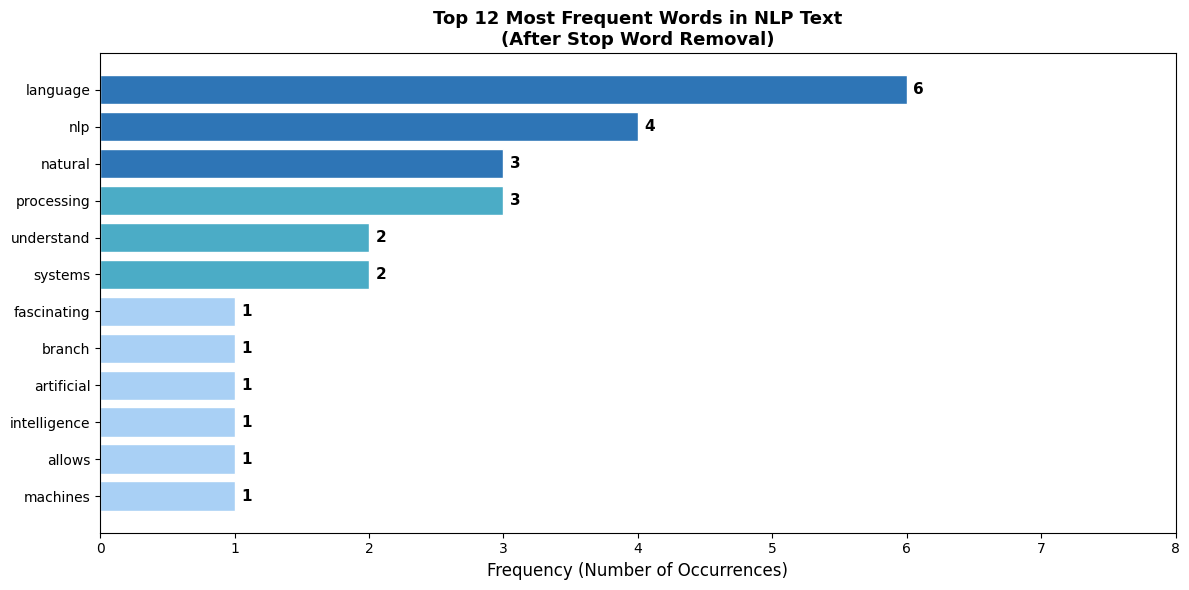

Fig 2: Horizontal bar chart saved.


In [5]:
# Word Frequency Bar Chart
# Visual representation of word frequencies
import matplotlib.pyplot as plt
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

text = """
Natural Language Processing is a fascinating branch of Artificial Intelligence.
NLP allows machines to read, understand, and generate human language.
Deep learning has transformed Natural Language Processing significantly.
Modern NLP systems use neural networks to understand language patterns.
Applications of NLP include machine translation, chatbots, sentiment analysis,
speech recognition, text summarization, and spam detection systems.
Python is the most popular programming language for Natural Language Processing.
NLTK and TensorFlow are commonly used tools in NLP development.
"""

stop_words = set(stopwords.words('english'))
tokens = word_tokenize(text.lower())
clean_tokens = [w for w in tokens if w.isalpha() and w not in stop_words]
word_freq = Counter(clean_tokens)

# Get top 12 words
top_words  = [w for w, c in word_freq.most_common(12)]
top_counts = [c for w, c in word_freq.most_common(12)]

# CHART 1: Horizontal bar chart
plt.figure(figsize=(12, 6))
colors = ['#2E75B6' if i < 3 else '#4BACC6' if i < 6 else '#A9D0F5'
          for i in range(len(top_words))]
bars = plt.barh(top_words[::-1], top_counts[::-1], color=colors[::-1],
                edgecolor='white')

for bar, count in zip(bars, top_counts[::-1]):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=11, fontweight='bold')

plt.xlabel('Frequency (Number of Occurrences)', fontsize=12)
plt.title('Top 12 Most Frequent Words in NLP Text\n(After Stop Word Removal)',
          fontsize=13, fontweight='bold')
plt.xlim(0, max(top_counts) + 2)
plt.tight_layout()
plt.savefig('word_frequency_bar.png', dpi=150)
plt.show()
print("Fig 2: Horizontal bar chart saved.")

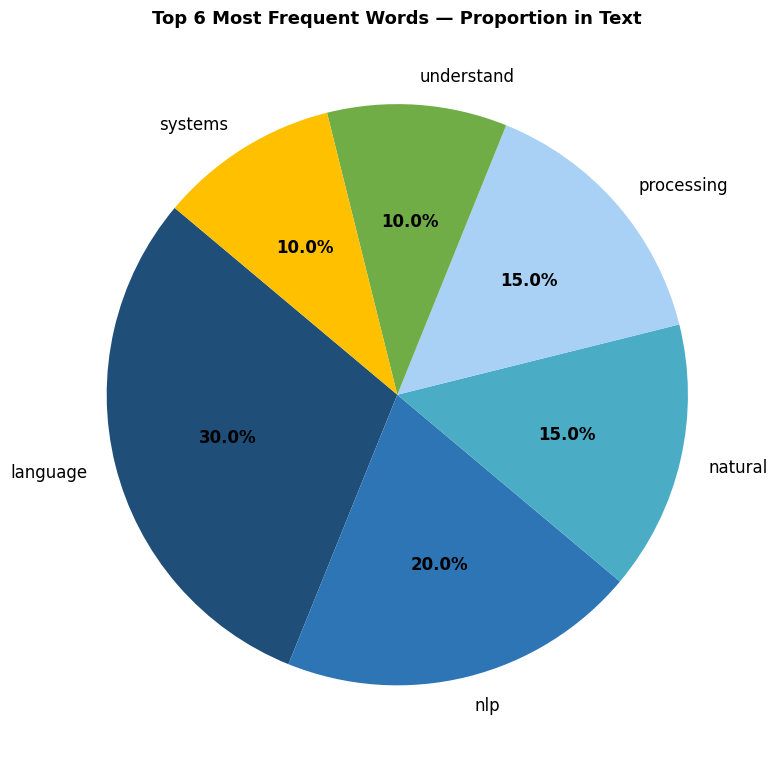

Fig 3: Pie chart saved.


In [6]:
# EXTRA WORK - Fig 3: Pie Chart of Top 6 Words
import matplotlib.pyplot as plt

top6_words  = [w for w, c in word_freq.most_common(6)]
top6_counts = [c for w, c in word_freq.most_common(6)]

colors = ['#1F4E79','#2E75B6','#4BACC6','#A9D0F5','#70AD47','#FFC000']

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    top6_counts,
    labels=top6_words,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')

plt.title('Top 6 Most Frequent Words — Proportion in Text',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('word_frequency_pie.png', dpi=150)
plt.show()
print("Fig 3: Pie chart saved.")

In [7]:
# Applying Word Frequency to Spam Dataset
# Comparing spam vs ham word frequencies
import pandas as pd
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df  = pd.read_csv(url, sep='\t', header=None, names=['label','message'])

stop_words = set(stopwords.words('english'))

def get_top_words(messages, n=10):
    all_tokens = []
    for msg in messages:
        tokens = word_tokenize(str(msg).lower())
        all_tokens.extend([w for w in tokens if w.isalpha()
                           and w not in stop_words])
    return Counter(all_tokens).most_common(n)

spam_words = get_top_words(df[df['label']=='spam']['message'])
ham_words  = get_top_words(df[df['label']=='ham']['message'])

print("TOP 10 WORDS IN SPAM MESSAGES:")
print("=" * 40)
for word, count in spam_words:
    print(f"  '{word}': {count} times  {'█' * (count // 5)}")

print("\nTOP 10 WORDS IN HAM (LEGITIMATE) MESSAGES:")
print("=" * 40)
for word, count in ham_words:
    print(f"  '{word}': {count} times  {'█' * (count // 10)}")

TOP 10 WORDS IN SPAM MESSAGES:
  'call': 346 times  █████████████████████████████████████████████████████████████████████
  'free': 219 times  ███████████████████████████████████████████
  'txt': 156 times  ███████████████████████████████
  'ur': 144 times  ████████████████████████████
  'u': 142 times  ████████████████████████████
  'mobile': 123 times  ████████████████████████
  'text': 121 times  ████████████████████████
  'stop': 118 times  ███████████████████████
  'claim': 113 times  ██████████████████████
  'reply': 104 times  ████████████████████

TOP 10 WORDS IN HAM (LEGITIMATE) MESSAGES:
  'u': 994 times  ███████████████████████████████████████████████████████████████████████████████████████████████████
  'gt': 318 times  ███████████████████████████████
  'lt': 316 times  ███████████████████████████████
  'get': 302 times  ██████████████████████████████
  'go': 251 times  █████████████████████████
  'ur': 247 times  ████████████████████████
  'ok': 246 times  ████████████████

In [8]:
# EXTRA WORK SECTION 3
# SYNTAX Sentence Structure Analysis
# Syntax deals with grammar and sentence structure
import nltk
from nltk import pos_tag, word_tokenize, RegexpParser

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

print("NLP COMPONENT 1: SYNTAX")
print("=" * 60)
print("Syntax = the rules that govern sentence structure and grammar")
print()

# Syntactically CORRECT sentences
correct_sentences = [
    "The student studies Natural Language Processing.",
    "Python is a powerful programming language for NLP.",
    "The quick brown fox jumps over the lazy dog.",
    "Nairobi is the capital city of Kenya."
]

# Syntactically INCORRECT sentences (wrong grammar)
incorrect_sentences = [
    "Student the NLP studies.",        # wrong word order
    "Is Python powerful a language.",  # wrong order
    "Fox the lazy jumps brown over."   # scrambled
]

print("SYNTACTICALLY CORRECT SENTENCES — POS Tag Analysis:")
print("-" * 60)
for sent in correct_sentences:
    tokens = word_tokenize(sent)
    tags   = pos_tag(tokens)
    print(f"\nSentence : {sent}")
    print(f"Structure: {tags}")

print("\n\nSYNTACTICALLY INCORRECT SENTENCES:")
print("-" * 60)
for sent in incorrect_sentences:
    tokens = word_tokenize(sent)
    tags   = pos_tag(tokens)
    print(f"\nSentence : {sent}")
    print(f"Structure: {tags}")
    print(f"  ⚠ This sentence has incorrect grammar/word order")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...


NLP COMPONENT 1: SYNTAX
Syntax = the rules that govern sentence structure and grammar

SYNTACTICALLY CORRECT SENTENCES — POS Tag Analysis:
------------------------------------------------------------

Sentence : The student studies Natural Language Processing.
Structure: [('The', 'DT'), ('student', 'NN'), ('studies', 'NNS'), ('Natural', 'NNP'), ('Language', 'NNP'), ('Processing', 'NNP'), ('.', '.')]

Sentence : Python is a powerful programming language for NLP.
Structure: [('Python', 'NNP'), ('is', 'VBZ'), ('a', 'DT'), ('powerful', 'JJ'), ('programming', 'NN'), ('language', 'NN'), ('for', 'IN'), ('NLP', 'NNP'), ('.', '.')]

Sentence : The quick brown fox jumps over the lazy dog.
Structure: [('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN'), ('.', '.')]

Sentence : Nairobi is the capital city of Kenya.
Structure: [('Nairobi', 'NNP'), ('is', 'VBZ'), ('the', 'DT'), ('capital', 'NN'), ('city', 'NN'

[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [9]:
# SEMANTICS Word Meaning and Ambiguity
# Semantics deals with the meaning of words and sentences
from nltk.corpus import wordnet
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLP COMPONENT 2: SEMANTICS")
print("=" * 60)
print("Semantics = the study of meaning in language")
print()

# Demonstrate word ambiguity same word, multiple meanings
ambiguous_words = ['bank', 'bat', 'bark', 'spring', 'light']

print("WORD AMBIGUITY — One word, multiple meanings:")
print("-" * 60)
for word in ambiguous_words:
    synsets = wordnet.synsets(word)
    print(f"\nWord: '{word}'")
    print(f"Number of different meanings: {len(synsets)}")
    for i, syn in enumerate(synsets[:3], 1):
        definition = syn.definition()
        example    = syn.examples()[0] if syn.examples() else "No example"
        print(f"  Meaning {i}: {definition}")
        print(f"  Example : {example}")

print("\n")
print("KEY INSIGHT: This is why NLP is hard.")
print("The word 'bank' has", len(wordnet.synsets('bank')), "different meanings.")
print("Computers must use CONTEXT to determine which meaning is correct.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


NLP COMPONENT 2: SEMANTICS
Semantics = the study of meaning in language

WORD AMBIGUITY — One word, multiple meanings:
------------------------------------------------------------

Word: 'bank'
Number of different meanings: 18
  Meaning 1: sloping land (especially the slope beside a body of water)
  Example : they pulled the canoe up on the bank
  Meaning 2: a financial institution that accepts deposits and channels the money into lending activities
  Example : he cashed a check at the bank
  Meaning 3: a long ridge or pile
  Example : a huge bank of earth

Word: 'bat'
Number of different meanings: 10
  Meaning 1: nocturnal mouselike mammal with forelimbs modified to form membranous wings and anatomical adaptations for echolocation by which they navigate
  Example : No example
  Meaning 2: (baseball) a turn trying to get a hit
  Example : he was at bat when it happened
  Meaning 3: a small racket with a long handle used for playing squash
  Example : No example

Word: 'bark'
Number of 

[nltk_data]   Package omw-1.4 is already up-to-date!


In [10]:
# PRAGMATICS Context and Intended Meaning
# Pragmatics = what is actually meant vs what is literally said
print("NLP COMPONENT 3: PRAGMATICS")
print("=" * 60)
print("Pragmatics = understanding intended meaning from context")
print()

# Examples of pragmatic ambiguity
pragmatic_examples = [
    {
        "sentence": "Can you pass the salt?",
        "literal":  "Asking whether you HAVE THE ABILITY to pass salt",
        "actual":   "A polite REQUEST to pass the salt",
        "context":  "Said at a dinner table"
    },
    {
        "sentence": "It's cold in here.",
        "literal":  "Stating that the temperature is low",
        "actual":   "A REQUEST to close the window or turn on the heater",
        "context":  "Said to someone sitting near an open window"
    },
    {
        "sentence": "Do you know what time it is?",
        "literal":  "Asking if you have knowledge of the current time",
        "actual":   "A REQUEST to tell me the current time",
        "context":  "Said to someone wearing a watch"
    },
    {
        "sentence": "Nice weather for ducks.",
        "literal":  "The weather is suitable for ducks",
        "actual":   "Sarcastic complaint about RAINY weather",
        "context":  "Said while it is raining heavily"
    },
    {
        "sentence": "Your phone is ringing.",
        "literal":  "Informing you that your phone is making a sound",
        "actual":   "A REQUEST or hint that you should answer your phone",
        "context":  "Said when someone is ignoring a ringing phone"
    }
]

for i, ex in enumerate(pragmatic_examples, 1):
    print(f"Example {i}:")
    print(f"  Sentence      : \"{ex['sentence']}\"")
    print(f"  Context       : {ex['context']}")
    print(f"  Literal meaning: {ex['literal']}")
    print(f"  Actual meaning : {ex['actual']}")
    print()

print("WHY PRAGMATICS MATTERS IN NLP:")
print("-" * 60)
print("  Chatbots must understand INTENT, not just words.")
print("  'Can you book me a flight?' means BOOK THE FLIGHT")
print("  not 'Yes/No — do you have the ability to book flights?'")
print()
print("  This is why simple keyword-matching chatbots fail.")
print("  Modern AI (ChatGPT) uses pragmatic understanding")
print("  to respond to what you MEAN, not just what you SAY.")

NLP COMPONENT 3: PRAGMATICS
Pragmatics = understanding intended meaning from context

Example 1:
  Sentence      : "Can you pass the salt?"
  Context       : Said at a dinner table
  Literal meaning: Asking whether you HAVE THE ABILITY to pass salt
  Actual meaning : A polite REQUEST to pass the salt

Example 2:
  Sentence      : "It's cold in here."
  Context       : Said to someone sitting near an open window
  Literal meaning: Stating that the temperature is low
  Actual meaning : A REQUEST to close the window or turn on the heater

Example 3:
  Sentence      : "Do you know what time it is?"
  Context       : Said to someone wearing a watch
  Literal meaning: Asking if you have knowledge of the current time
  Actual meaning : A REQUEST to tell me the current time

Example 4:
  Sentence      : "Nice weather for ducks."
  Context       : Said while it is raining heavily
  Literal meaning: The weather is suitable for ducks
  Actual meaning : Sarcastic complaint about RAINY weather

Exa

In [11]:
# All Three Components Applied Together
# Showing Syntax + Semantics + Pragmatics on one sentence
import nltk
from nltk.corpus import wordnet

sentence = "The bank by the river was closed yesterday."

print("ALL THREE NLP COMPONENTS — APPLIED TO ONE SENTENCE")
print("=" * 65)
print(f"Sentence: \"{sentence}\"")
print()

# 1. SYNTAX — what is the grammatical structure?
tokens = nltk.word_tokenize(sentence)
tags   = nltk.pos_tag(tokens)
print("1. SYNTAX — Grammatical Structure:")
print("-" * 45)
tag_map = {
    'DT':'Determiner','NN':'Noun','NNP':'Proper Noun',
    'NNS':'Noun(plural)','VBD':'Verb(past)','VBZ':'Verb',
    'IN':'Preposition','RB':'Adverb','JJ':'Adjective'
}
for word, tag in tags:
    print(f"   {word:<15} → {tag_map.get(tag, tag)}")

# 2. SEMANTICS what does the ambiguous word mean?
print("\n2. SEMANTICS — Word 'bank' is ambiguous:")
print("-" * 45)
bank_meanings = wordnet.synsets('bank')
print(f"   'bank' has {len(bank_meanings)} possible meanings.")
print(f"   Meaning A: {bank_meanings[0].definition()}")
print(f"   Meaning B: {bank_meanings[3].definition()}")
print(f"   Context clue: 'by the river' → likely means RIVER BANK")

# 3. PRAGMATICS what does the whole sentence imply?
print("\n3. PRAGMATICS — What is the intended meaning?")
print("-" * 45)
print("   Literal  : A financial bank near a river was not open")
print("   Pragmatic: If said by someone trying to withdraw money,")
print("              it implies FRUSTRATION and means")
print("              'I could not get my money today'")
print()
print("   CONCLUSION:")
print("   Full NLP understanding requires all three levels:")
print("   Syntax  → Is the sentence grammatically correct?")
print("   Semantics  → What do the words mean?")
print("   Pragmatics → What did the speaker actually intend?")

ALL THREE NLP COMPONENTS — APPLIED TO ONE SENTENCE
Sentence: "The bank by the river was closed yesterday."

1. SYNTAX — Grammatical Structure:
---------------------------------------------
   The             → Determiner
   bank            → Noun
   by              → Preposition
   the             → Determiner
   river           → Noun
   was             → Verb(past)
   closed          → VBN
   yesterday       → Noun
   .               → .

2. SEMANTICS — Word 'bank' is ambiguous:
---------------------------------------------
   'bank' has 18 possible meanings.
   Meaning A: sloping land (especially the slope beside a body of water)
   Meaning B: an arrangement of similar objects in a row or in tiers
   Context clue: 'by the river' → likely means RIVER BANK

3. PRAGMATICS — What is the intended meaning?
---------------------------------------------
   Literal  : A financial bank near a river was not open
   Pragmatic: If said by someone trying to withdraw money,
              it implie

In [12]:
# EXTRA WORK SECTION 4
# Syntactic Parsing Chunking
# Extracting Noun Phrases (NP) and Verb Phrases (VP)
import nltk
from nltk import RegexpParser, pos_tag, word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

print("SYNTACTIC PARSING — NOUN PHRASE CHUNKING")
print("=" * 60)
print("Parsing = breaking a sentence into its grammatical parts")
print("Chunk   = a group of words that form a meaningful phrase")
print()

# Define grammar rules for chunking
# NP = Noun Phrase: optional determiner + optional adjectives + noun
grammar = r"""
    NP: {<DT>?<JJ>*<NN.*>+}
    VP: {<VB.*><NP|PP>*}
    PP: {<IN><NP>}
"""

chunk_parser = RegexpParser(grammar)

sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "Natural Language Processing is a fascinating field of Artificial Intelligence.",
    "John builds intelligent chatbots using Python and NLTK.",
    "The SMS spam classifier detects fraudulent messages automatically.",
    "Deep learning models process large amounts of text data efficiently."
]

for i, sentence in enumerate(sentences, 1):
    tokens = word_tokenize(sentence)
    tags   = pos_tag(tokens)
    tree   = chunk_parser.parse(tags)

    # Extract noun phrases
    noun_phrases = []
    for subtree in tree.subtrees():
        if subtree.label() == 'NP':
            np = ' '.join(word for word, tag in subtree.leaves())
            noun_phrases.append(np)

    print(f"Sentence {i}: {sentence}")
    print(f"  POS Tags     : {tags}")
    print(f"  Noun Phrases : {noun_phrases}")
    print()

SYNTACTIC PARSING — NOUN PHRASE CHUNKING
Parsing = breaking a sentence into its grammatical parts
Chunk   = a group of words that form a meaningful phrase

Sentence 1: The quick brown fox jumps over the lazy dog.
  POS Tags     : [('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN'), ('.', '.')]
  Noun Phrases : ['The quick brown fox', 'the lazy dog']

Sentence 2: Natural Language Processing is a fascinating field of Artificial Intelligence.
  POS Tags     : [('Natural', 'JJ'), ('Language', 'NNP'), ('Processing', 'NNP'), ('is', 'VBZ'), ('a', 'DT'), ('fascinating', 'JJ'), ('field', 'NN'), ('of', 'IN'), ('Artificial', 'JJ'), ('Intelligence', 'NNP'), ('.', '.')]
  Noun Phrases : ['Natural Language Processing', 'a fascinating field', 'Artificial Intelligence']

Sentence 3: John builds intelligent chatbots using Python and NLTK.
  POS Tags     : [('John', 'NNP'), ('builds', 'VBZ'), ('intelligent', 'JJ'

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [13]:
# Dependency-Style Analysis
# Understanding which words depend on which
import nltk

print("SENTENCE DEPENDENCY ANALYSIS")
print("=" * 60)
print("Which words are the most important (head) in each phrase?")
print()

sentences = [
    "The student quickly submits the important assignment.",
    "Barack Obama visited Nairobi for an important conference.",
    "The NLP model accurately classifies spam messages."
]

tag_map = {
    'DT':'Determiner','NN':'Noun','NNP':'Proper Noun',
    'NNS':'Noun(plural)','VBD':'Verb(past)','VBZ':'Verb',
    'IN':'Preposition','RB':'Adverb','JJ':'Adjective',
    'PRP':'Pronoun','CC':'Conjunction','VBP':'Verb',
    'VB':'Verb(base)','VBG':'Verb(gerund)','MD':'Modal'
}

for i, sentence in enumerate(sentences, 1):
    tokens = nltk.word_tokenize(sentence)
    tags   = nltk.pos_tag(tokens)

    # Separate into word types
    nouns   = [w for w, t in tags if t.startswith('NN')]
    verbs   = [w for w, t in tags if t.startswith('VB')]
    adjs    = [w for w, t in tags if t.startswith('JJ')]
    advs    = [w for w, t in tags if t.startswith('RB')]

    print(f"Sentence {i}: {sentence}")
    print(f"  Full POS Analysis:")
    for word, tag in tags:
        print(f"    {word:<15} → {tag_map.get(tag, tag)}")
    print(f"  Nouns   (entities/subjects): {nouns}")
    print(f"  Verbs   (actions)          : {verbs}")
    print(f"  Adjectives (descriptions)  : {adjs}")
    print(f"  Adverbs (modifiers)        : {advs}")
    print()

SENTENCE DEPENDENCY ANALYSIS
Which words are the most important (head) in each phrase?

Sentence 1: The student quickly submits the important assignment.
  Full POS Analysis:
    The             → Determiner
    student         → Noun
    quickly         → Adverb
    submits         → Verb
    the             → Determiner
    important       → Adjective
    assignment      → Noun
    .               → .
  Nouns   (entities/subjects): ['student', 'assignment']
  Verbs   (actions)          : ['submits']
  Adjectives (descriptions)  : ['important']
  Adverbs (modifiers)        : ['quickly']

Sentence 2: Barack Obama visited Nairobi for an important conference.
  Full POS Analysis:
    Barack          → Proper Noun
    Obama           → Proper Noun
    visited         → Verb(past)
    Nairobi         → Proper Noun
    for             → Preposition
    an              → Determiner
    important       → Adjective
    conference      → Noun
    .               → .
  Nouns   (entities/subjects

In [14]:
# Semantic Similarity
# How similar are two sentences in meaning?
from nltk.corpus import wordnet
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

print("SEMANTIC SIMILARITY — How similar are words in meaning?")
print("=" * 60)
print("Using WordNet path similarity: 1.0 = identical, 0.0 = unrelated")
print()

# Word pairs to compare
word_pairs = [
    ('dog',    'cat'),
    ('dog',    'animal'),
    ('car',    'vehicle'),
    ('spam',   'fraud'),
    ('happy',  'joyful'),
    ('happy',  'sad'),
    ('school', 'university'),
    ('phone',  'computer'),
    ('run',    'walk'),
    ('NLP',    'programming')
]

print(f"{'Word 1':<15} {'Word 2':<15} {'Similarity Score':<20} {'Interpretation'}")
print("-" * 70)

for w1, w2 in word_pairs:
    syns1 = wordnet.synsets(w1)
    syns2 = wordnet.synsets(w2)

    if syns1 and syns2:
        score = syns1[0].path_similarity(syns2[0])
        if score is None:
            score = 0.0
        if score >= 0.5:
            interpretation = "Very similar"
        elif score >= 0.2:
            interpretation = "Somewhat similar"
        elif score > 0:
            interpretation = "Distantly related"
        else:
            interpretation = "Not related"
    else:
        score = 0.0
        interpretation = "Not in WordNet"

    print(f"  {w1:<15} {w2:<15} {score:<20.3f} {interpretation}")

print("\nWHY SEMANTIC SIMILARITY MATTERS IN NLP:")
print("  Search engines use this to return relevant results")
print("  even when you use different words than the document.")
print("  Google understands 'automobile' and 'car' mean the same thing.")

SEMANTIC SIMILARITY — How similar are words in meaning?
Using WordNet path similarity: 1.0 = identical, 0.0 = unrelated

Word 1          Word 2          Similarity Score     Interpretation
----------------------------------------------------------------------
  dog             cat             0.200                Somewhat similar
  dog             animal          0.333                Somewhat similar
  car             vehicle         0.200                Somewhat similar
  spam            fraud           0.056                Distantly related
  happy           joyful          0.333                Somewhat similar
  happy           sad             0.333                Somewhat similar
  school          university      0.143                Distantly related
  phone           computer        0.143                Distantly related
  run             walk            0.100                Distantly related
  NLP             programming     0.071                Distantly related

WHY SEMANTIC S

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
